<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
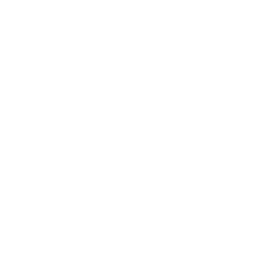
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Analyse van curriculumovereenkomst</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Hoger onderwijs / Ontwerp van academische programma's &nbsp;|&nbsp; maart 2026</p>
</div>
</div>
</div>

## Managementsamenvatting

Dit notebook meet de overlap tussen curricula in een universitaire vakkencatalogus met **PROC DISTANCE** en **METHOD=DJACCARD** — de Jaccard-*dissimilariteitscoëfficiënt*, de natuurlijke afstand voor binaire aanwezigheids-/afwezigheidsgegevens. Elk vak draagt 40 binaire vlaggen die aangeven welke accreditatie-leeruitkomsten het behandelt, dus de Jaccard-afstand tussen twee vakken is het aandeel behandelde uitkomsten dat ze **niet** gemeen hebben (0 = identieke uitkomstverzamelingen, 1 = geen gedeelde uitkomst).

De analyse verloopt in twee delen. Ten eerste profileert ze, over een catalogus van 100 vakken, de breedte van de uitkomstdekking per afdeling (PROC MEANS, PROC FREQ, een dekkingsboxplot) en markeert ze leeruitkomsten die **geen enkel** vak binnen een afdeling behandelt (dekkingshiaten). Ten tweede zoomt ze in op een gericht panel van 10 vakken uit de twee kwantitatief meest overlappende afdelingen — Statistiek en Datawetenschap — berekent ze de volledige paarsgewijze Jaccard-afstandsmatrix en rangschikt ze de dichtstbijzijnde vakparen als kandidaten voor consolidatiebeoordeling. Het doel is een curriculumcommissie twee concrete producten te geven: een gerangschikte lijst van de meest vergelijkbare vakken en een hiaatkaart van afdeling versus uitkomst.

## Gegevensbronnen

| Bron | Beschrijving | Records |
|--------|-------------|---------|
| WORK.COURSE_OUTCOMES | Binaire leeruitkomstdekking per vak (40 uitkomstvlaggen) | 100 |
| WORK.PANEL10 | Consolidatiepanel Statistiek + Datawetenschap | 10 |

De catalogus is synthetisch. De uitkomstvlaggen worden getrokken met afdelingsspecifieke kansen zodat disciplines verschillende uitkomstclusters benadrukken (informatica en wiskunde leggen gewicht op de vroege uitkomsten, de laboratoriumwetenschappen op de middenband), wat de afstandsanalyse een realistische structuur geeft. Deze omgeving draait zonder licentie, dus de werkcatalogus is beperkt tot 100 vakken.

---

In [1]:
/* --------------------------------------------------------
   Genereer een synthetische vak-leeruitkomstmatrix
   500 vakken x 40 accreditatie-leeruitkomsten
   (licentieloze modus behoudt de eerste 100)
   -------------------------------------------------------- */
GEGEVENS work.course_outcomes;
    CALL streaminit(42);
    REEKS outcomes[40] lo_1 - lo_40;
    REEKS dept_list[8] $15 _temporary_ ('INFORMATICA' 'WISKUNDE' 'STATISTIEK' 'TECHNIEK' 'BIOLOGIE' 'SCHEIKUNDE' 'NATUURKUNDE' 'DATAWETENSCHAP');
    DOE course_id = 1 TOT 500;
        course_label = cat('CRS', SCHRIJVEN(course_id, z4.));
        dept_idx = int(rand('uniform') * 8) + 1;
        department = dept_list[dept_idx];
        /* Vakniveau bepaalt de breedte van de uitkomsten */
        course_level = int(rand('uniform') * 4) + 1;
        level_code = course_level * 100;
        /* Afdelingsspecifieke uitkomstclusters */
        DOE lo = 1 TOT 40;
            base_prob = 0.15;
            /* Afd. 1-2 (Informatica, Wiskunde): nadruk op uitkomsten 1-15 */
            ALS dept_idx <= 2 AND lo <= 15 DAN
                base_prob = 0.4 + course_level * 0.05;
            /* Afd. 3-4 (Statistiek, Techniek): nadruk op uitkomsten 10-25 */
            ANDERS ALS dept_idx in (3, 4) AND 10 <= lo <= 25 DAN
                base_prob = 0.35 + course_level * 0.05;
            /* Afd. 5-7 (Biologie, Scheikunde, Natuurkunde): nadruk op 20-35 */
            ANDERS ALS dept_idx in (5, 6, 7) AND 20 <= lo <= 35 DAN
                base_prob = 0.38 + course_level * 0.04;
            /* Afd. 8 (Datawetenschap): brede dekking */
            ANDERS ALS dept_idx = 8 DAN
                base_prob = 0.25 + course_level * 0.03;
            outcomes[lo] = (rand('uniform') < base_prob);
        EINDE;
        UITVOER;
    EINDE;
    VERWIJDEREN dept_idx course_level base_prob lo;
UITVOEREN;


NOTE: DATA work.course_outcomes

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.course_outcomes (100 rows, 44 columns).
NOTE: DATA elapsed:
  wall  1.92 seconds
  cpu   1.92 seconds


In [2]:
/* --------------------------------------------------------
   Genereer metadata voor de vakkencatalogus
   -------------------------------------------------------- */
GEGEVENS work.course_catalog;
    CALL streaminit(43);
    REEKS dept_list[8] $15 _temporary_ ('INFORMATICA' 'WISKUNDE' 'STATISTIEK' 'TECHNIEK' 'BIOLOGIE' 'SCHEIKUNDE' 'NATUURKUNDE' 'DATAWETENSCHAP');
    REEKS format_list[3] $12 _temporary_ ('HOORCOLLEGE' 'PRACTICUM' 'WERKGROEP');
    DOE course_id = 1 TOT 500;
        course_label = cat('CRS-', SCHRIJVEN(course_id, z4.));
        dept_idx = int(rand('uniform') * 8) + 1;
        department = dept_list[dept_idx];
        level_code = (int(rand('uniform') * 4) + 1) * 100;
        credit_hours = int(rand('uniform') * 3) + 2;
        format_idx = int(rand('uniform') * 3) + 1;
        delivery_format = format_list[format_idx];
        enrollment_cap = int(rand('uniform') * 150) + 20;
        avg_enrollment = int(enrollment_cap * (rand('uniform') * 0.5 + 0.4));
        last_offered = '01JAN2025'd + int(rand('uniform') * 365);
        UITVOER;
    EINDE;
    VERWIJDEREN dept_idx format_idx;
    OPMAAK last_offered date9.;
UITVOEREN;


NOTE: DATA work.course_catalog

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.course_catalog (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.09 seconds
  cpu   0.09 seconds


---

                                      Basisdekking van leeruitkomsten per afdeling                                      

                                                  The MEANS Procedure

                                               Analysis Variable : lo_1

                                                              N
                                          Afdeling          Obs           Mean
                                          ------------------------------------
                                          BIOLOGIE           10      0.2000000
                                          DATAWETENSCHAP     14      0.1428571
                                          INFORMATICA        13      0.3846154
                                          NATUURKUNDE         7      0.2857143
                                          SCHEIKUNDE         19      0.2105263
                                          STATISTIEK         11      0.0909091
                                      


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_department_level_code.spec.json
NOTE: PROC FREQ statement used.


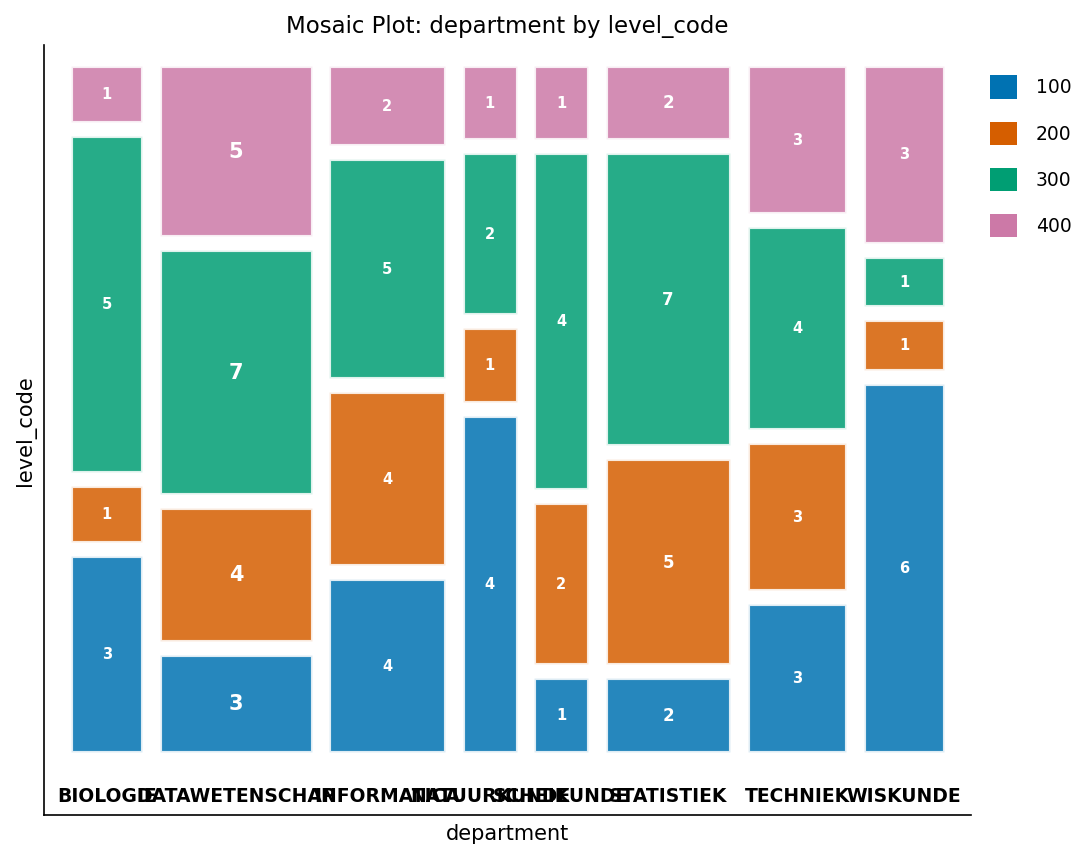

In [3]:
/* --------------------------------------------------------
   Basisdekking van leeruitkomsten per afdeling
   -------------------------------------------------------- */
PROCEDURE GEMIDDELDEN GEGEVENS=work.course_outcomes mean;
    KLASSE department;
    VARIABELE lo_1 - lo_40;
    LABEL department='Afdeling';
    TITEL 'Basisdekking van leeruitkomsten per afdeling';
UITVOEREN;

PROCEDURE FREQUENTIES GEGEVENS=work.course_catalog;
    TABLES department * level_code / nopercent norow nocol;
    LABEL department='Afdeling' level_code='Niveau';
    TITEL 'Vakken per afdeling en niveau';
UITVOEREN;

---

                                             Vakken per afdeling en niveau                                              




NOTE: DATA work.outcome_counts


NOTE: Read 100 rows from work.course_outcomes.
NOTE: Wrote work.outcome_counts (100 rows, 45 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds
NOTE: PROC SGPLOT data=work.outcome_counts

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


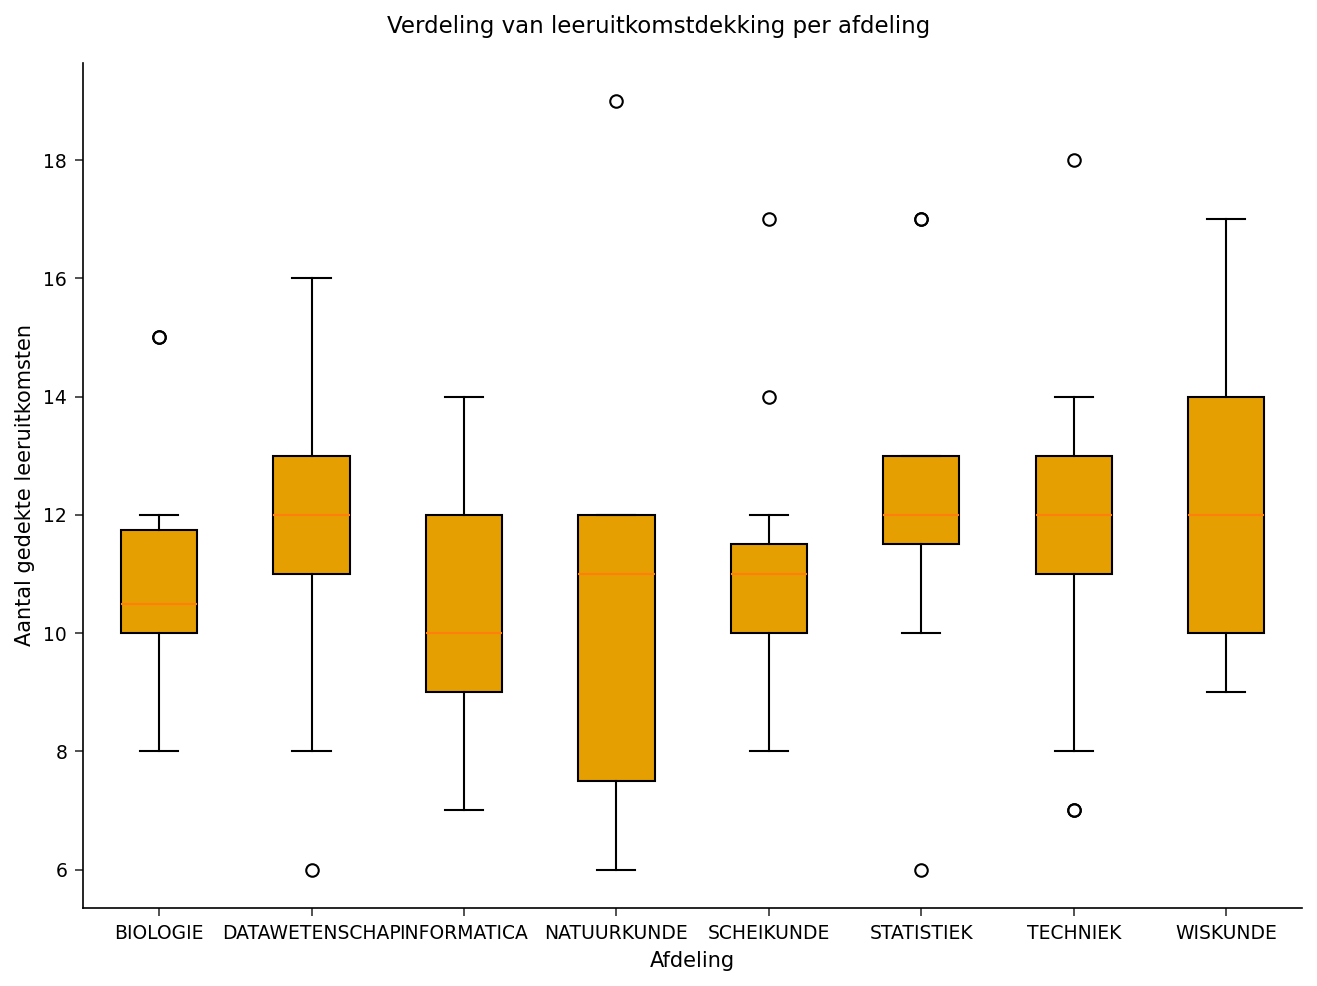

In [4]:
/* --------------------------------------------------------
   Dichtheid van uitkomstdekking per afdeling
   -------------------------------------------------------- */
GEGEVENS work.outcome_counts;
    INSTELLEN work.course_outcomes;
    REEKS outcomes[40] lo_1 - lo_40;
    total_outcomes = sum(OF outcomes[*]);
UITVOEREN;

PROCEDURE SGPLOT GEGEVENS=work.outcome_counts;
    VBOX total_outcomes / category=department;
    YAXIS label='Aantal gedekte leeruitkomsten';
    XAXIS label='Afdeling';
    TITEL 'Verdeling van leeruitkomstdekking per afdeling';
UITVOEREN;

---

In [5]:
/* --------------------------------------------------------
   Consolidatiepanel: de eerste 10 vakken uit Statistiek /
   Datawetenschap (de twee kwantitatief meest overlappende
   afdelingen). Herlabel ze P01-P10 met een oplopende teller
   zodat de vierkante afstandsmatrix OUT= schone,
   adresseerbare kolommen heeft, en bereken vervolgens de
   volledige paarsgewijze Jaccard-afstandsmatrix met
   METHOD=DJACCARD (0 = identieke uitkomstverzamelingen,
   1 = geen gedeelde uitkomst).
   -------------------------------------------------------- */
GEGEVENS work.panel10;
    INSTELLEN work.course_outcomes(WAAR=(department in ('STATISTIEK' 'DATAWETENSCHAP')));
    BEHOUDEN seq 0;
    seq + 1;
    ALS seq > 10 DAN STOPPEN;
    panel_id = cat('P', SCHRIJVEN(seq, z2.));
    VERWIJDEREN seq;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=work.panel10 noobs label;
    VARIABELE panel_id course_label department level_code;
    label panel_id = 'Panel-ID' course_label = 'Vak'
          department = 'Afdeling' level_code = 'Niveau';
    TITEL 'Consolidatiepanel: vakken Statistiek en Datawetenschap';
UITVOEREN;

PROCEDURE distance GEGEVENS=work.panel10
              out=work.panel_dist
              METHOD=djaccard;
    VARIABELE nominal(lo_1 - lo_40);
    id panel_id;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=work.panel_dist noobs;
    TITEL 'Paarsgewijze Jaccard-afstandsmatrix (10 vakken)';
UITVOEREN;

                                 Consolidatiepanel: vakken Statistiek en Datawetenschap                                 

Panel-ID      Vak        Afdeling  Niveau
P01       CRS0003  DATAWETENSCHAP     300
P02       CRS0006  STATISTIEK         300
P03       CRS0014  DATAWETENSCHAP     300
P04       CRS0015  STATISTIEK         300
P05       CRS0017  STATISTIEK         200
P06       CRS0019  DATAWETENSCHAP     100
P07       CRS0022  STATISTIEK         400
P08       CRS0033  DATAWETENSCHAP     200
P09       CRS0038  STATISTIEK         100
P10       CRS0040  STATISTIEK         100

                                 Consolidatiepanel: vakken Statistiek en Datawetenschap                                 

                                    Paarsgewijze Jaccard-afstandsmatrix (10 vakken)                                     

_NAME_           P01           P02           P03           P04           P05           P06           P07           P08           P09           P10
P01                0  0.


NOTE: DATA work.panel10


NOTE: Read 41 rows from work.course_outcomes.
NOTE: Wrote work.panel10 (10 rows, 45 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC PRINT data=work.panel10

NOTE: PROC PRINT completed: 10 observations printed, 4 variables
NOTE: PROC DISTANCE data=work.panel10 method=Djaccard

NOTE: PROC DISTANCE: 10 observations, 40 variables, method=Djaccard
NOTE: PROC PRINT data=work.panel_dist

NOTE: PROC PRINT completed: 10 observations printed, 11 variables


In [6]:
/* --------------------------------------------------------
   Herstructureer de vierkante afstandsmatrix tot een
   gerangschikte lijst van vakparen. De afstandskolommen
   OUT= worden aangesproken via een expliciete namenlijst
   (P01 P02 ... P10); alleen de strikte bovendriehoek
   (col > row) wordt behouden zodat elk ongeordend paar
   eenmaal voorkomt en de nuldiagonaal wordt overgeslagen.
   De vijf dichtstbijzijnde paren zijn de kandidaten voor
   consolidatiebeoordeling.
   -------------------------------------------------------- */
GEGEVENS work.similar_courses;
    INSTELLEN work.panel_dist;
    REEKS d[10] P01 P02 P03 P04 P05 P06 P07 P08 P09 P10;
    LENGTE course_a course_b $8;
    course_a = _name_;
    row + 1;
    DOE col = 1 TOT 10;
        ALS col > row DAN DOE;
            course_b     = vname(d[col]);
            jaccard_dist = round(d[col], 0.001);
            UITVOER;
        EINDE;
    EINDE;
    BEWAREN course_a course_b jaccard_dist;
UITVOEREN;

PROCEDURE GEMIDDELDEN GEGEVENS=work.similar_courses n MIN q1 MEDIAN mean MAX maxdec=3;
    VARIABELE jaccard_dist;
    LABEL jaccard_dist='Jaccard-afstand';
    TITEL 'Verdeling van paarsgewijze Jaccard-afstanden (45 vakparen)';
UITVOEREN;

PROCEDURE SORTEREN GEGEVENS=work.similar_courses; VOLGENS jaccard_dist; UITVOEREN;

GEGEVENS work.top_pairs;
    INSTELLEN work.similar_courses;
    pair_rank = _n_;
    ALS pair_rank <= 5;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=work.top_pairs noobs label;
    VARIABELE pair_rank course_a course_b jaccard_dist;
    label pair_rank = 'Rang' course_a = 'Vak A'
          course_b = 'Vak B' jaccard_dist = 'Jaccard-afstand';
    TITEL 'Vijf dichtstbijzijnde vakparen (consolidatiekandidaten)';
UITVOEREN;

                               Verdeling van paarsgewijze Jaccard-afstanden (45 vakparen)                               

                                                  The MEANS Procedure

 Variable      Label                  N     Minimum   Lower Quartile      Median        Mean     Maximum
 -------------------------------------------------------------------------------------------------------
 jaccard_dist  Jaccard-afstand       45       0.588            0.762       0.826       0.818       0.962
 -------------------------------------------------------------------------------------------------------

                                Vijf dichtstbijzijnde vakparen (consolidatiekandidaten)                                 

Rang  Vak A  Vak B  Jaccard-afstand
   1  P02    P10              0.588
   2  P03    P04                0.6
   3  P03    P05              0.667
   4  P02    P04              0.684
   5  P02    P07              0.684




NOTE: DATA work.similar_courses


NOTE: Read 10 rows from work.panel_dist.
NOTE: Wrote work.similar_courses (45 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=work.similar_courses

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 45 rows from work.similar_courses.
NOTE: Wrote work.similar_courses (45 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.top_pairs


NOTE: Read 45 rows from work.similar_courses.
NOTE: Wrote work.top_pairs (5 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.top_pairs

NOTE: PROC PRINT completed: 5 observations printed, 4 variables


                                        Niet-gedekte leeruitkomsten per afdeling                                        

                                                   The FREQ Procedure

Afdeling       Frequency    Percent
------------------------------------
BIOLOGIE               8     26.67
INFORMATICA            3     10.00
NATUURKUNDE            8     26.67
SCHEIKUNDE             2      6.67
STATISTIEK             3     10.00
TECHNIEK               2      6.67
WISKUNDE               4     13.33
                                    Voorbeeld van uitkomsthiaten (eerste 12 van 30)                                     

   Afdeling  Niet-gedekte uitkomst
BIOLOGIE     LO02
BIOLOGIE     LO10
BIOLOGIE     LO15
BIOLOGIE     LO16
BIOLOGIE     LO17
BIOLOGIE     LO18
BIOLOGIE     LO36
BIOLOGIE     LO37
INFORMATICA  LO29
INFORMATICA  LO35
INFORMATICA  LO36
NATUURKUNDE  LO02

... 18 more observations (showing 12 of 30)




NOTE: PROC MEANS
NOTE: Output dataset work.dept_coverage has 8 observations and 43 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.outcome_gaps


NOTE: Read 8 rows from work.dept_coverage.
NOTE: Wrote work.outcome_gaps (30 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_department.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC PRINT data=work.outcome_gaps

NOTE: PROC PRINT completed: 12 observations printed, 2 variables


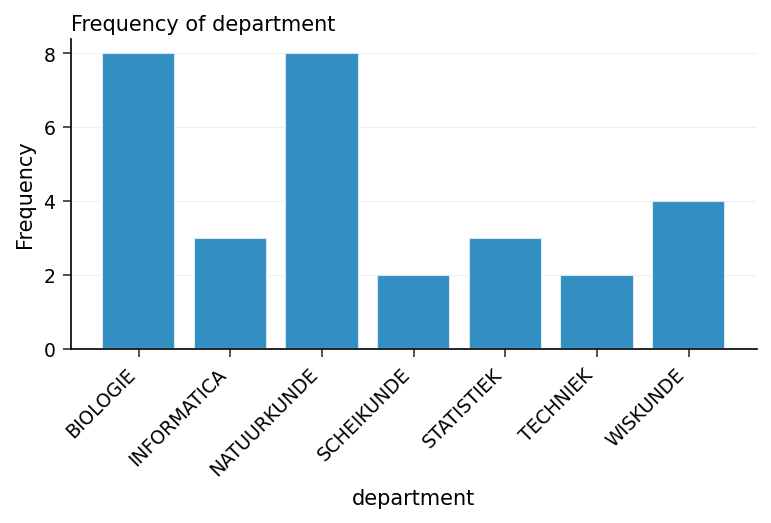

In [7]:
/* --------------------------------------------------------
   Uitkomsthiaten: leeruitkomsten die GEEN ENKEL vak in een
   afdeling behandelt. PROC MEANS sommeert elke binaire
   uitkomstvlag binnen de afdeling; een som van nul betekent
   dat de uitkomst ontbreekt in de catalogus van die afdeling.
   -------------------------------------------------------- */
PROCEDURE GEMIDDELDEN GEGEVENS=work.course_outcomes sum NOPRINT;
    KLASSE department;
    VARIABELE lo_1 - lo_40;
    UITVOER out=work.dept_coverage(WAAR=(_type_=1))
        sum=lo_1 - lo_40;
UITVOEREN;

GEGEVENS work.outcome_gaps;
    INSTELLEN work.dept_coverage;
    REEKS outcomes[40] lo_1 - lo_40;
    DOE lo = 1 TOT 40;
        outcome_id = cat('LO', SCHRIJVEN(lo, z2.));
        courses_covering = outcomes[lo];
        ALS courses_covering = 0 DAN DOE;
            gap_flag = 1;
            UITVOER;
        EINDE;
    EINDE;
    BEWAREN department outcome_id courses_covering gap_flag;
UITVOEREN;

PROCEDURE FREQUENTIES GEGEVENS=work.outcome_gaps;
    TABLES department / nocum;
    LABEL department='Afdeling';
    TITEL 'Niet-gedekte leeruitkomsten per afdeling';
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=work.outcome_gaps(obs=12) noobs label;
    VARIABELE department outcome_id;
    label department = 'Afdeling' outcome_id = 'Niet-gedekte uitkomst';
    TITEL 'Voorbeeld van uitkomsthiaten (eerste 12 van 30)';
UITVOEREN;

---

### Interpretatie

**Consolidatiepanel.** Over de 45 ongeordende paren in het panel van 10 Statistiek-/Datawetenschap-vakken varieert de Jaccard-afstand van 0.588 tot 0.962, met een mediaan van 0.826 (gemiddelde 0.818). Het dichtstbijzijnde paar is P02 en P10 op afstand 0.588, gevolgd door P03–P04 op 0.600 en P03–P05 op 0.667. Zelfs de meest vergelijkbare vakken verschillen nog op ongeveer 59% van hun behandelde uitkomsten, dus deze catalogus bevat **geen bijna-duplicaatvakken** — er is geen paar dat een commissie zonder meer zou kunnen samenvoegen. In plaats daarvan wijst de gerangschikte lijst op het handjevol paren dat een handmatige syllabusvergelijking waard is vóór de volgende cataloguscyclus; de paren met de grootste afstand (bijna 0.962) bevestigen dat Statistiek- en Datawetenschap-vakken, ondanks dat ze tot dezelfde afdelingsomgeving behoren, werkelijk verschillende uitkomstverzamelingen beslaan.

**Uitkomsthiaten.** Er komen dertig hiaten van afdeling versus uitkomst naar voren in de catalogus. De laboratoriumintensieve disciplines dragen de meeste: **Biologie** en **Natuurkunde** laten elk 8 van de 40 accreditatie-uitkomsten onbehandeld, gevolgd door **Wiskunde** (4). De kwantitatieve afdelingen zijn het best gedekt — **Scheikunde** en **Techniek** missen elk slechts 2 uitkomsten. Deze hiaten zijn de natuurlijke doelen voor nieuwe vakontwikkeling of cross-listing: een uitkomst die in een hele afdeling ontbreekt, is een dekkingsrisico bij accreditatievernieuwing, terwijl de consolidatielijst het tegenovergestelde probleem van dubbel werk aanpakt. Samen stellen de twee producten de commissie in staat de catalogus van twee kanten aan te scherpen — overlap wegsnijden en woestijnen opvullen — met één op verzamelingen gebaseerde afstandsmaat.

---

In [8]:
/* --------------------------------------------------------
   Exporteer de gerangschikte consolidatiekandidaten en de
   afdelings-uitkomsthiaatkaart voor de curriculumcommissie.
   -------------------------------------------------------- */
PROCEDURE EXPORTEREN GEGEVENS=work.similar_courses
    OUTFILE='curriculum_consolidation_candidates.csv'
    DBMS=csv REPLACE;
UITVOEREN;

PROCEDURE EXPORTEREN GEGEVENS=work.outcome_gaps
    OUTFILE='curriculum_outcome_gaps.csv'
    DBMS=csv REPLACE;
UITVOEREN;


NOTE: PROC EXPORT data=work.similar_courses outfile=curriculum_consolidation_candidates.csv

NOTE: Exported 45 rows to curriculum_consolidation_candidates.csv.
NOTE: PROC EXPORT data=work.outcome_gaps outfile=curriculum_outcome_gaps.csv

NOTE: Exported 30 rows to curriculum_outcome_gaps.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Vertrouwelijk
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Mogelijk gemaakt door <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>